In [14]:
# 02_spending_kmeans.ipynb

# 1. DATA LOADING

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Load preprocessed data
df = pd.read_csv("preprocessed_customer_data.csv")

In [16]:
# 2. FEATURE SELECTION (Spending behavior)

spending_features = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]
X = df[spending_features]

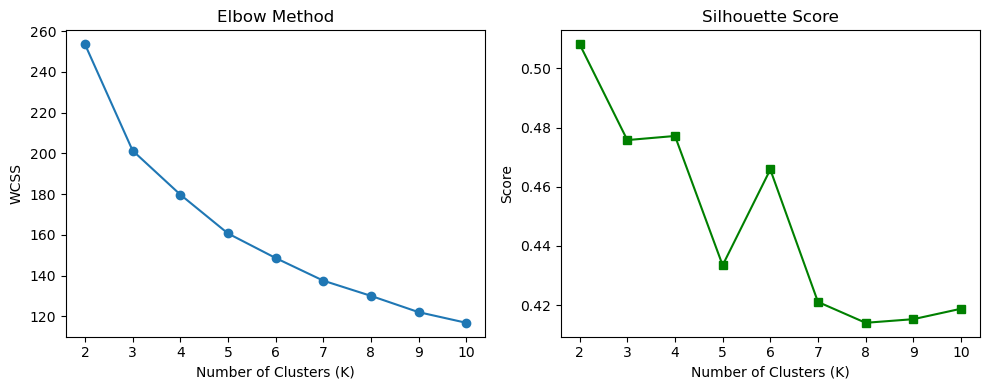

In [18]:
# 3. DETERMINE OPTIMAL K (Elbow method (WCSS)+ Silhouette Score)

wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='s', color='green')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [19]:
# 4. APPLY K-MEANS WITH OPTIMAL K

# Choose optimal k (based on plots above)
optimal_k = 4  # Example: choose 4 if silhouette and elbow suggest it

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['SpendingCluster'] = kmeans.fit_predict(X)

📊 Average Spending per Cluster:


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
SpendingCluster,,,,,,
0,0.063229,0.029901,0.023365,0.031056,0.022761,0.060475
1,0.580404,0.153049,0.176061,0.152773,0.114366,0.189762
2,0.235127,0.204431,0.177166,0.305792,0.234297,0.273362
3,0.370348,0.592988,0.271434,0.551890,0.349228,0.281446


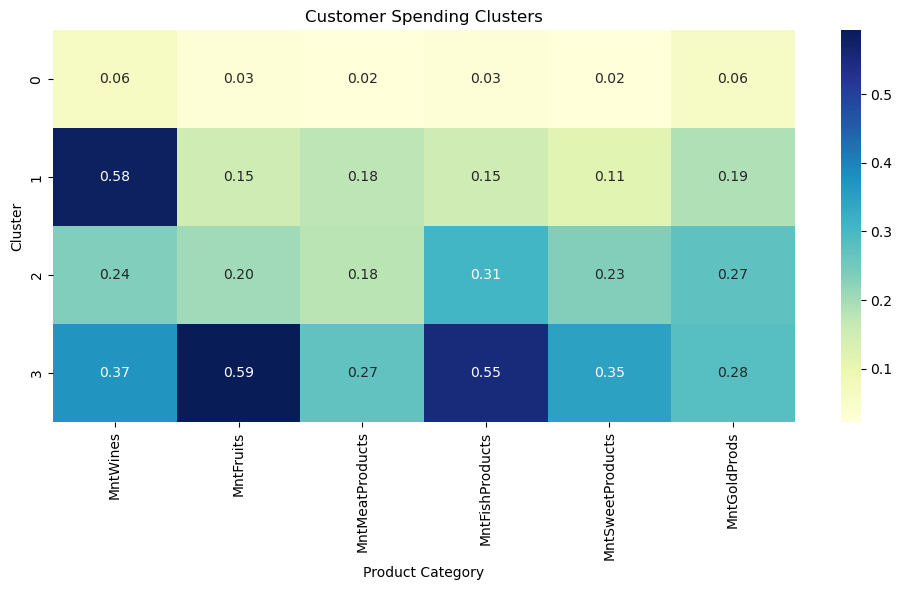

In [20]:
# 5. CLUSTER PROFILE ANALYSIS

# Average spending per product by cluster
cluster_profile = df.groupby('SpendingCluster')[spending_features].mean()

print("📊 Average Spending per Cluster:")
display(cluster_profile)

# Plot cluster profile as heatmap for easy comparison
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Customer Spending Clusters")
plt.ylabel("Cluster")
plt.xlabel("Product Category")
plt.tight_layout()
plt.show()

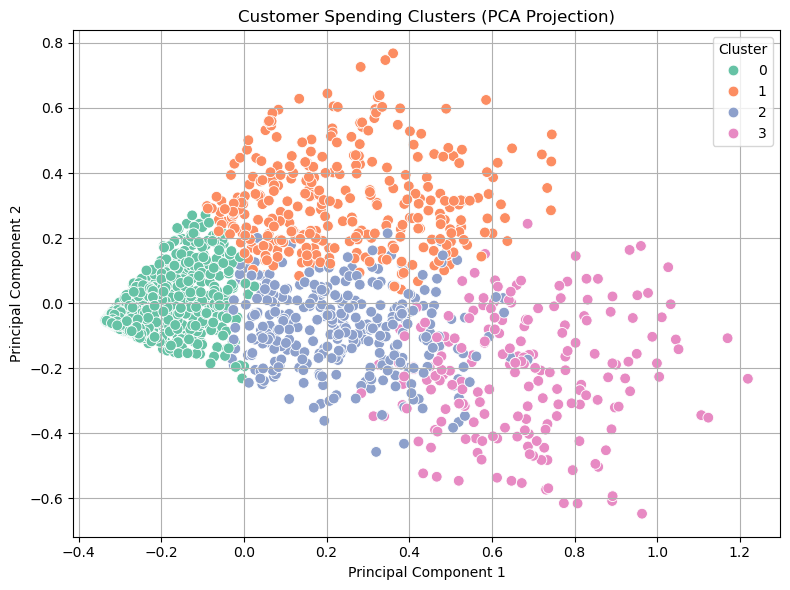

In [24]:
# 5A. VISUALIZE CLUSTERS USING PCA (2D)

# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['SpendingCluster']

# Plot the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60)
plt.title("Customer Spending Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()